In [ ]:
import pandas as pd
import numpy as np
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
project_path = "/content/drive/MyDrive/music-success-analytics"

processed_path = project_path + "/processed"
quality_reports_path = project_path + "/quality_reports"

In [ ]:
file_path = processed_path + "/spotify_tracks_clean.csv"

df = pd.read_csv(file_path)

df.head()

,track_id,track_name,artist_name,album_name,release_date,release_year,genre,duration_ms,duration_min,popularity,...,key,loudness,mode,instrumentalness,tempo,stream_count,country,explicit,label,label_type
0,TRK-BEBD53DA84E1,Agent every (0),Noah Rhodes,Beautiful instead,2016-04-01,2016,Pop,234194,3.90,55,...,9,-32.22,0,0.436,73.12,13000,Brazil,0,Universal Music,Label
1,TRK-6A32496762D7,Night respond,Jennifer Cole,Table,2022-04-15,2022,Metal,375706,6.26,45,...,0,-14.02,0,0.223,157.74,1000,France,1,Island Records,Label
2,TRK-47AA7523463E,Future choice whatever,Brandon Davis,Page southern,2016-02-23,2016,Rock,289191,4.82,55,...,8,-48.26,1,0.584,71.03,1000,Germany,1,XL Recordings,Label
3,TRK-25ADA22E3B06,Bad fall pick those,Corey Jones,Spring,2015-10-12,2015,Pop,209484,3.49,51,...,1,-34.47,1,0.684,149.00,1000,France,0,Warner Music,Label
4,TRK-9245F2AD996A,Husband,Mark Diaz,Great prove,2022-07-08,2022,Indie,127435,2.12,39,...,10,-17.84,0,0.304,155.85,2000,United States,0,Independent,Independent


In [ ]:
df.shape

(84979, 23)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84979 entries, 0 to 84978
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_id          84979 non-null  object 
 1   track_name        84979 non-null  object 
 2   artist_name       84979 non-null  object 
 3   album_name        84979 non-null  object 
 4   release_date      84979 non-null  object 
 5   release_year      84979 non-null  int64  
 6   genre             84979 non-null  object 
 7   duration_ms       84979 non-null  int64  
 8   duration_min      84979 non-null  float64
 9   popularity        84979 non-null  int64  
 10  is_hit            84979 non-null  int64  
 11  danceability      84979 non-null  float64
 12  energy            84979 non-null  float64
 13  key               84979 non-null  int64  
 14  loudness          84979 non-null  float64
 15  mode              84979 non-null  int64  
 16  instrumentalness  84979 non-null  float6

# Machine Learning - Hit Prediction

This notebook builds a machine learning model to predict whether a Spotify track can be classified as a hit.

The target variable is `is_hit`, where:

- `1` = Hit track
- `0` = Non-hit track

The `popularity` column is excluded from the model because `is_hit` was created using the popularity distribution. Including `popularity` would cause data leakage and would make the model unrealistically accurate.

In [ ]:
df["is_hit"].value_counts()

,count
is_hit,
0,63731
1,21248


In [ ]:
df["is_hit"].value_counts(normalize=True).round(2)

,proportion
is_hit,
0,0.75
1,0.25


## Target Distribution

The target variable is moderately imbalanced, with non-hit tracks representing around 75% of the dataset and hit tracks around 25%.  
For this reason, model evaluation should not rely only on accuracy. Precision, recall and F1-score will also be considered.

In [ ]:
feature_columns = [
    "danceability",
    "energy",
    "loudness",
    "instrumentalness",
    "tempo",
    "duration_min",
    "explicit",
    "release_year",
    "genre",
    "country",
    "label_type"
]

target_column = "is_hit"

X = df[feature_columns]
y = df[target_column]

X.head()

,danceability,energy,loudness,instrumentalness,tempo,duration_min,explicit,release_year,genre,country,label_type
0,0.15,0.74,-32.22,0.436,73.12,3.90,0,2016,Pop,Brazil,Label
1,0.44,0.46,-14.02,0.223,157.74,6.26,1,2022,Metal,France,Label
2,0.62,0.80,-48.26,0.584,71.03,4.82,1,2016,Rock,Germany,Label
3,0.78,0.98,-34.47,0.684,149.00,3.49,0,2015,Pop,France,Label
4,0.74,0.18,-17.84,0.304,155.85,2.12,0,2022,Indie,United States,Independent


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

numeric_features = [
    "danceability",
    "energy",
    "loudness",
    "instrumentalness",
    "tempo",
    "duration_min",
    "explicit",
    "release_year"
]

categorical_features = [
    "genre",
    "country",
    "label_type"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((67983, 11), (16996, 11), (67983,), (16996,))

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_features = [
    "danceability",
    "energy",
    "loudness",
    "instrumentalness",
    "tempo",
    "duration_min",
    "explicit",
    "release_year"
]

categorical_features = [
    "genre",
    "country",
    "label_type"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

preprocessor

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['danceability', 'energy', 'loudness',
                                  'instrumentalness', 'tempo', 'duration_min',
                                  'explicit', 'release_year']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['genre', 'country', 'label_type'])])

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

log_reg_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
    ]
)

log_reg_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['danceability', 'energy',
                                                   'loudness',
                                                   'instrumentalness', 'tempo',
                                                   'duration_min', 'explicit',
                                                   'release_year']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['genre', 'country',
                                                   'label_type'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

log_reg_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
    ]
)

log_reg_model.fit(X_train, y_train)

y_pred_log_reg = log_reg_model.predict(X_test)

print("Logistic Regression Results")
print("Accuracy:", round(accuracy_score(y_test, y_pred_log_reg), 4))
print("Precision:", round(precision_score(y_test, y_pred_log_reg), 4))
print("Recall:", round(recall_score(y_test, y_pred_log_reg), 4))
print("F1-score:", round(f1_score(y_test, y_pred_log_reg), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log_reg))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log_reg))

Logistic Regression Results
Accuracy: 0.5084
Precision: 0.2542
Recall: 0.4995
F1-score: 0.3369

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.51      0.61     12746
           1       0.25      0.50      0.34      4250

    accuracy                           0.51     16996
   macro avg       0.50      0.51      0.47     16996
weighted avg       0.63      0.51      0.54     16996


Confusion Matrix:
[[6517 6229]
 [2127 2123]]


### Logistic Regression Baseline Results

The Logistic Regression model was used as a baseline classification model.

The model achieved an accuracy of around 51%, which indicates limited predictive performance.  
For the hit class, recall is around 50%, meaning that the model is able to identify about half of the actual hit tracks. However, precision is low, meaning that many tracks predicted as hits are actually non-hits.

This result suggests that the selected audio and metadata features contain some signal, but they are not strong enough for highly accurate hit prediction using a simple linear model.

The Logistic Regression model will be used as a baseline for comparison with more advanced models.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=100,
            max_depth=10,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Results")
print("Accuracy:", round(accuracy_score(y_test, y_pred_rf), 4))
print("Precision:", round(precision_score(y_test, y_pred_rf), 4))
print("Recall:", round(recall_score(y_test, y_pred_rf), 4))
print("F1-score:", round(f1_score(y_test, y_pred_rf), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Results
Accuracy: 0.6157
Precision: 0.2493
Recall: 0.2668
F1-score: 0.2578

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.73      0.74     12746
           1       0.25      0.27      0.26      4250

    accuracy                           0.62     16996
   macro avg       0.50      0.50      0.50     16996
weighted avg       0.62      0.62      0.62     16996


Confusion Matrix:
[[9331 3415]
 [3116 1134]]


### Random Forest Results

The Random Forest model achieved higher overall accuracy than Logistic Regression, but performed worse in identifying hit tracks.

Although the accuracy increased to around 62%, the recall for the hit class was only about 27%. This means that the model correctly identified fewer than one third of the actual hit tracks.

Compared to Logistic Regression, Random Forest was more conservative and classified more tracks as non-hits. For this reason, Logistic Regression remains the more useful baseline model for this project, because it achieved a better balance between precision and recall for the hit class.

In [ ]:
model_results = pd.DataFrame({
    "model": ["Logistic Regression", "Random Forest"],
    "accuracy": [
        accuracy_score(y_test, y_pred_log_reg),
        accuracy_score(y_test, y_pred_rf)
    ],
    "precision": [
        precision_score(y_test, y_pred_log_reg),
        precision_score(y_test, y_pred_rf)
    ],
    "recall": [
        recall_score(y_test, y_pred_log_reg),
        recall_score(y_test, y_pred_rf)
    ],
    "f1_score": [
        f1_score(y_test, y_pred_log_reg),
        f1_score(y_test, y_pred_rf)
    ]
})

model_results.round(4)

,model,accuracy,precision,recall,f1_score
0,Logistic Regression,0.5084,0.2542,0.4995,0.3369
1,Random Forest,0.6157,0.2493,0.2668,0.2578


### Model Comparison

Two baseline classification models were tested: Logistic Regression and Random Forest.

Random Forest achieved a higher overall accuracy, but Logistic Regression performed better on the hit class in terms of recall and F1-score. Since the goal of this project is to identify potential hit tracks, recall is particularly important because it measures how many actual hit songs the model is able to detect.

Overall, Logistic Regression is selected as the more useful baseline model for this first version of the hit prediction task. However, the results also show that audio and metadata features alone have limited predictive power, and future improvements could include additional features such as playlist placements, marketing exposure, artist popularity history, social media trends and release strategy.

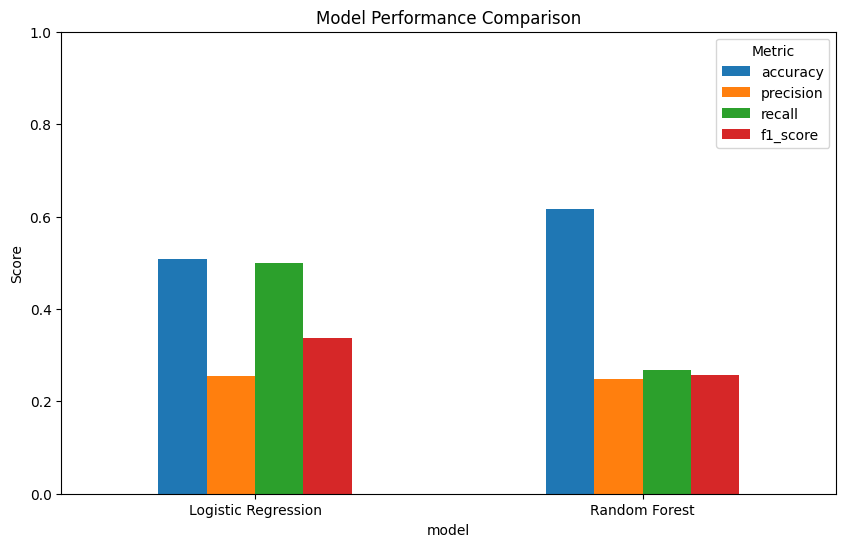

In [ ]:
import matplotlib.pyplot as plt

model_results.set_index("model")[["accuracy", "precision", "recall", "f1_score"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(title="Metric")
plt.show()

### Model Comparison

Two baseline classification models were tested: Logistic Regression and Random Forest.

Random Forest achieved a higher overall accuracy, but Logistic Regression obtained a better recall and F1-score for the hit class.

Since the objective of this project is to identify potential hit tracks, recall is particularly important: it measures how many actual hit tracks the model is able to detect.

For this reason, Logistic Regression can be considered the more useful baseline model for this specific business objective, even though the overall model performance remains limited.

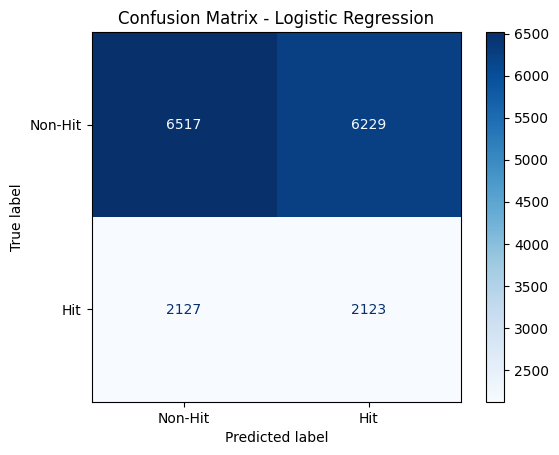

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_log_reg,
    display_labels=["Non-Hit", "Hit"],
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

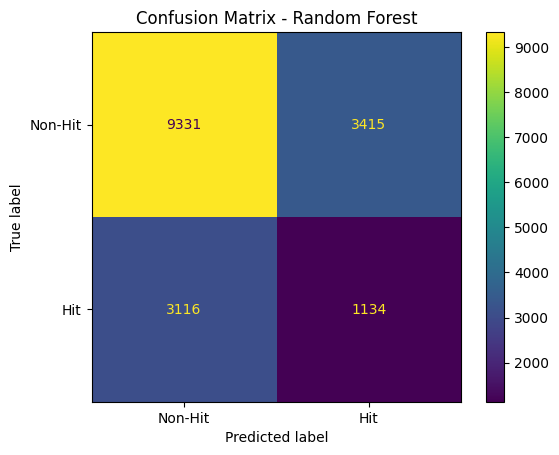

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Non-Hit", "Hit"]
)

disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

## Model Evaluation Summary

Two baseline classification models were tested to predict whether a track is a hit or a non-hit:

- Logistic Regression
- Random Forest Classifier

The dataset is moderately imbalanced, with around 75% non-hit tracks and 25% hit tracks. For this reason, accuracy alone is not enough to evaluate model performance. Precision, recall and F1-score are also important.

The Logistic Regression model achieved lower overall accuracy, but it identified a higher proportion of hit tracks compared to the Random Forest model. However, it also produced many false positives, meaning that many non-hit tracks were incorrectly classified as hits.

The Random Forest model achieved higher accuracy and performed better at identifying non-hit tracks. However, its recall for hit tracks was lower, meaning that many actual hit tracks were still missed.

Overall, both models show that predicting hit songs using only audio features and basic metadata is challenging. The results suggest that additional external features, such as playlist placement, marketing budget, artist popularity, social media activity or release strategy, would likely improve predictive performance.

In [ ]:
# Extract feature names after preprocessing
numeric_feature_names = numeric_features

categorical_feature_names = (
    rf_model.named_steps["preprocessor"]
    .named_transformers_["cat"]
    .get_feature_names_out(categorical_features)
)

all_feature_names = list(numeric_feature_names) + list(categorical_feature_names)

# Extract feature importance from Random Forest
feature_importances = rf_model.named_steps["classifier"].feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance": feature_importances
}).sort_values(by="importance", ascending=False)

feature_importance_df.head(20)

,feature,importance
4,tempo,0.133851
2,loudness,0.133420
3,instrumentalness,0.126308
5,duration_min,0.126158
0,danceability,0.106847
1,energy,0.106535
7,release_year,0.062707
6,explicit,0.014970
30,label_type_Independent,0.011524
31,label_type_Label,0.010511


### Feature Importance

The Random Forest model was used to inspect which features contributed the most to the hit prediction task.

The most relevant variables are mainly audio and track-level characteristics, such as tempo, loudness, instrumentalness, duration, danceability and energy.  
Categorical variables such as country, genre and label type appear to have a smaller impact on the model.

This suggests that, within this dataset, the distinction between hit and non-hit tracks is driven more by numerical/audio-related features than by geographic or label-related information.

## Machine Learning Results Summary

Two classification models were tested to predict whether a track could be classified as a hit or non-hit:

- Logistic Regression
- Random Forest Classifier

The target variable was moderately imbalanced, with approximately 75% non-hit tracks and 25% hit tracks. For this reason, model evaluation was based not only on accuracy, but also on precision, recall and F1-score.

## Model Comparison

The Logistic Regression model achieved an accuracy of 0.5084 and an F1-score of 0.3369 for the hit class. Although the overall accuracy is low, this model was better at identifying potential hit tracks compared to Random Forest. However, it also produced many false positives, meaning that several non-hit tracks were incorrectly classified as hits.

The Random Forest model achieved a higher overall accuracy of 0.6157, but a lower F1-score of 0.2578 for the hit class. This indicates that Random Forest was better at correctly identifying non-hit tracks, but weaker at detecting actual hit tracks.

## Best Model

For this specific business problem, Logistic Regression is the more useful baseline model because the main objective is to identify potential hit tracks. Even though Random Forest has higher accuracy, Logistic Regression provides better recall and F1-score for the hit class.

However, both models show limited predictive performance. This suggests that predicting music success using only audio features and basic metadata is difficult.

## Feature Importance

The Random Forest feature importance analysis shows that the most relevant variables were mainly audio and track-level features:

- tempo
- loudness
- instrumentalness
- duration_min
- danceability
- energy
- release_year

Categorical variables such as country, genre and label type had lower importance in this model.

## Final Considerations

The machine learning results should be interpreted as an exploratory baseline, not as a production-ready prediction system.

The analysis suggests that hit prediction likely depends on many external factors that are not included in this dataset, such as:

- marketing budget
- playlist placement
- artist popularity
- social media trends
- collaborations
- label promotion strategy

For this reason, the model is useful to demonstrate a complete machine learning workflow, including feature selection, preprocessing, model training, evaluation and interpretation, but its predictive power remains limited.

In [ ]:
ml_results_path = project_path + "/quality_reports/ml_model_results.csv"

model_results_export = model_results.round(4)

model_results_export.to_csv(ml_results_path, index=False)

ml_results_path

'/content/drive/MyDrive/music-success-analytics/quality_reports/ml_model_results.csv'

In [ ]:
feature_importance_path = project_path + "/quality_reports/ml_feature_importance.csv"

feature_importance_export = feature_importance_df.head(15).copy()
feature_importance_export["importance"] = feature_importance_export["importance"].round(4)

feature_importance_export.to_csv(feature_importance_path, index=False)

feature_importance_path

'/content/drive/MyDrive/music-success-analytics/quality_reports/ml_feature_importance.csv'

In [ ]:
import os

os.listdir(project_path + "/quality_reports")

['data_dictionary.xlsx',
 'spotify_data_quality_report.csv',
 'spotify_cleaning_summary.csv',
 'spotify_eda_overview.csv',
 'genre_analysis.csv',
 'hit_vs_non_hit_analysis.csv',
 'label_type_analysis.csv',
 'country_analysis.csv',
 'genre_label_type_analysis.csv',
 'correlation_matrix.csv',
 'eda_summary.csv',
 'sql_model_summary.csv',
 'ml_model_results.csv',
 'ml_feature_importance.csv']